## Task 2.1 - Simulating the income distribution

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display

import matplotlib.pyplot as plt

from dstapi import DstApi
from scipy.stats import norm

%load_ext autoreload
%autoreload 2

import dataproject_3 as dp

In [2]:
seed = 2026
rng = np.random.default_rng(seed)

N = 50_000                      # Number of individuals
Pe = [0.4, 0.35, 0.25]          # probabilities for education
Se = [1, 3, 5]                  # Years of education
He = [1.00, 1.20, 1.55]         # initial human capital
growth = [0.010, 0.020, 0.030]  # growth in human capital
depreciation = 0.06             # Depreciation while unemployed
std = 0.10                      # Standard deviation of shocks
job_finding = 0.60              # Job finding probability
job_separation = 0.05           # Job separation probability
grant = 0.45                    # Student Grant
replacement = 0.60              # Replacement rate
benefit_floor = 0.35 
start_age = 18                  # Start age
retire_age = 65                 # Retirement age

In [3]:
states, human_capital, income, ages, education_group = dp.simulate_income(
    N=N, Pe=Pe, Se=Se, He=He, growth=growth, depreciation=depreciation, std=std,
    job_finding=job_finding, job_separation=job_separation, grant=grant,
    replacement=replacement, benefit_floor=benefit_floor,
    start_age=start_age, retire_age=retire_age, seed=seed,
)


In [4]:
# Sanity checks: education shares should match Pe, and the unemployment
# rate should settle at the steady-state value sigma / (sigma + lambda)
shares = [np.mean(education_group == g) for g in range(3)]
print(f"Share in each education group: {shares[0]:.2f}, {shares[1]:.2f}, {shares[2]:.2f}" + f", Goal: {Pe[0]:.2f}, {Pe[1]:.2f}, {Pe[2]:.2f}")

target_unemployment_rate = (job_separation / (job_separation + job_finding))
print(f"Unemployment rate: {1 - np.mean(states):.3f}" + f", Goal: {target_unemployment_rate:.3f}")
print(f"Average human capital at retirement: {np.mean(human_capital):.3f}")


Share in each education group: 0.40, 0.35, 0.25, Goal: 0.40, 0.35, 0.25
Unemployment rate: 0.078, Goal: 0.077
Average human capital at retirement: 2.177


## Task 2.2 - Simulate the income distribution

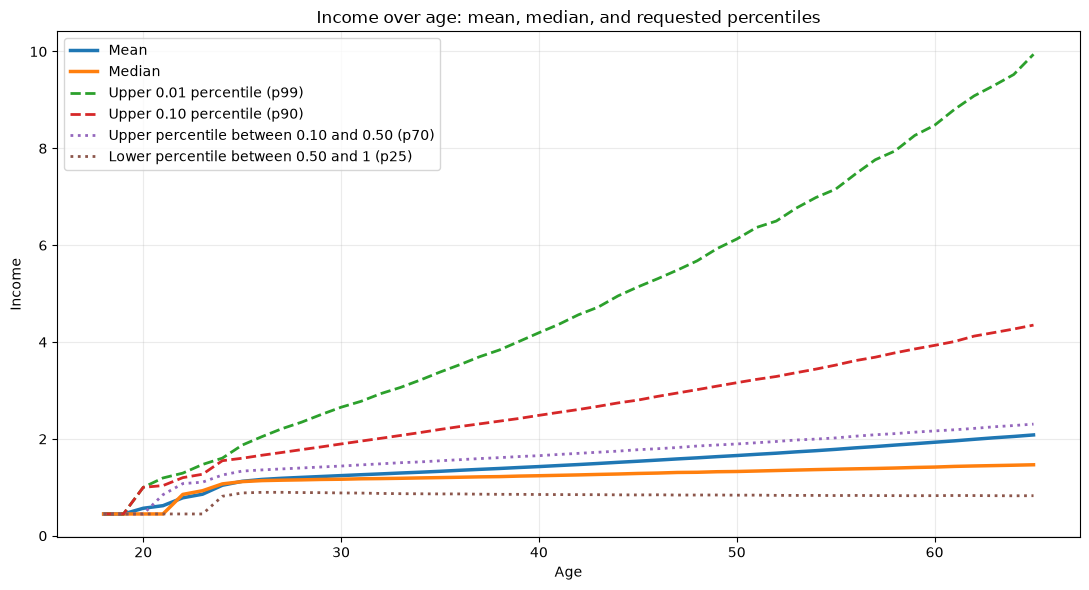

In [5]:
# Income summary by age
income_mean = income.mean(axis=0)
income_median = np.median(income, axis=0)

# Upper-tail percentiles
income_top_001 = np.percentile(income, 99, axis=0)  # top 0.01
income_top_010 = np.percentile(income, 90, axis=0)  # top 0.10
income_top_mid = np.percentile(income, 70, axis=0)  # between top 0.10 and top 0.50

# Lower-tail percentile between 0.50 and 1 (chosen as midpoint in lower half)
income_bottom_mid = np.percentile(income, 25, axis=0)

plt.figure(figsize=(11, 6))
plt.plot(ages, income_mean, label="Mean", linewidth=2.5)
plt.plot(ages, income_median, label="Median", linewidth=2.5)
plt.plot(ages, income_top_001, label="Upper 0.01 percentile (p99)", linewidth=2.0, linestyle="--")
plt.plot(ages, income_top_010, label="Upper 0.10 percentile (p90)", linewidth=2.0, linestyle="--")
plt.plot(ages, income_top_mid, label="Upper percentile between 0.10 and 0.50 (p70)", linewidth=2.0, linestyle=":")
plt.plot(ages, income_bottom_mid, label="Lower percentile between 0.50 and 1 (p25)", linewidth=2.0, linestyle=":")

plt.title("Income over age: mean, median, and requested percentiles")
plt.xlabel("Age")
plt.ylabel("Income")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

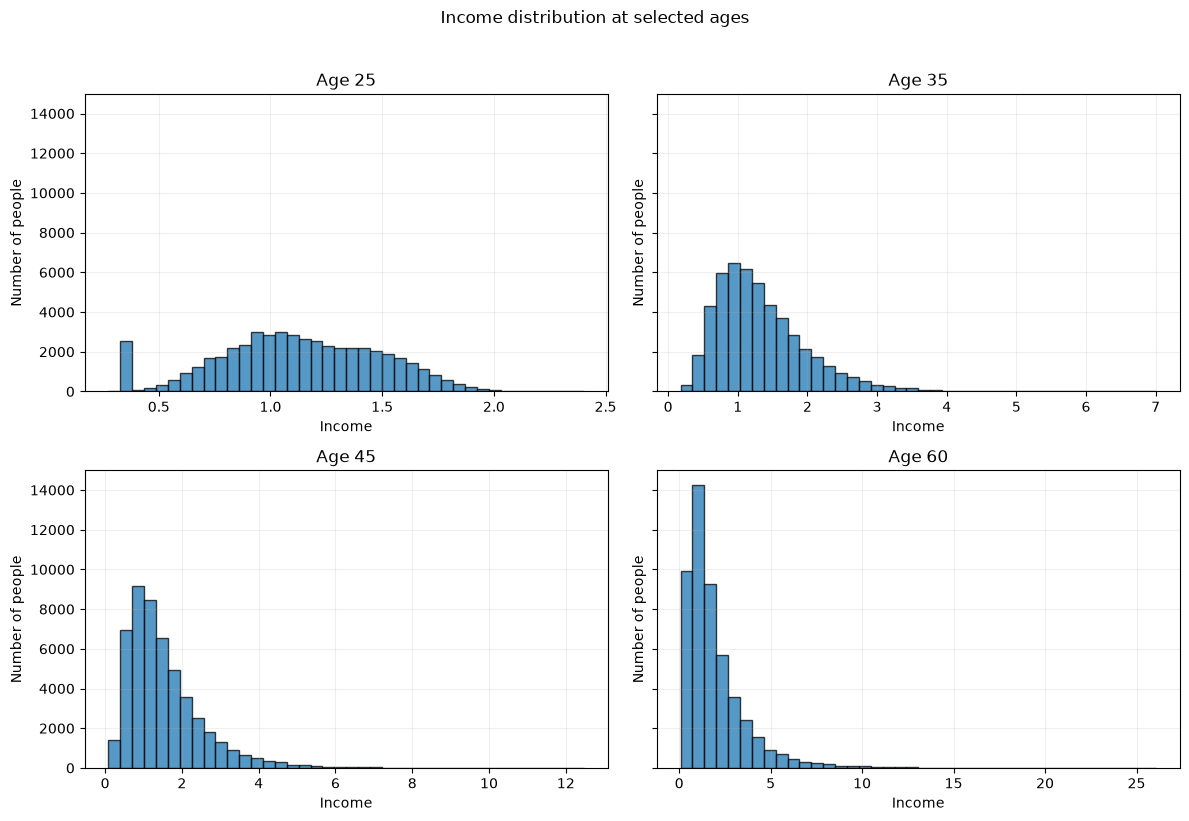

In [6]:
# Histograms of income distribution at selected ages
ages_to_plot = [25, 35, 45, 60]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for i, age in enumerate(ages_to_plot):
    age_idx = np.where(ages == age)[0][0]
    axes[i].hist(income[:, age_idx], bins=40, edgecolor="black", alpha=0.75)
    axes[i].set_title(f"Age {age}")
    axes[i].set_xlabel("Income")
    axes[i].set_ylabel("Number of people")
    axes[i].grid(alpha=0.2)

plt.suptitle("Income distribution at selected ages", y=1.02)
plt.tight_layout()
plt.show()

The income distribution widens and becomes increasingly right-skewed with age. While incomes are relatively concentrated at age 25, the spread grows at ages 35 and 45, and by age 60 a pronounced upper tail has emerged. This reflects rising income inequality over the life cycle as differences in labor market outcomes and human capital accumulate

## Task 2.3 - Compute the Gini coefficient

In [7]:
# Example: Gini at selected ages
gini_by_age = {}
for age in [25, 35, 45, 60]:
    age_idx = np.where(ages == age)[0][0]
    gini_by_age[age] = dp.gini_coefficient(income[:, age_idx])

#Test
uniform_random_numbers = rng.uniform(0, 1, size=100000)
gini_uniform = dp.gini_coefficient(uniform_random_numbers)
print("Gini coefficient for uniform random numbers: " + f"{gini_uniform: .2f}" + ", Expected: 0.33")

lognormal_random_numbers = rng.lognormal(mean=0, sigma=1, size=100000)
gini_lognormal = dp.gini_coefficient(lognormal_random_numbers)
expected_gini_lognormal = 2 * norm.cdf(1 / np.sqrt(2)) - 1
print("Gini coefficient for lognormal random numbers: " + f"{gini_lognormal: .2f}" + ", Expected:" + f"{expected_gini_lognormal: .2f}")


Gini coefficient for uniform random numbers:  0.33, Expected: 0.33
Gini coefficient for lognormal random numbers:  0.52, Expected: 0.52


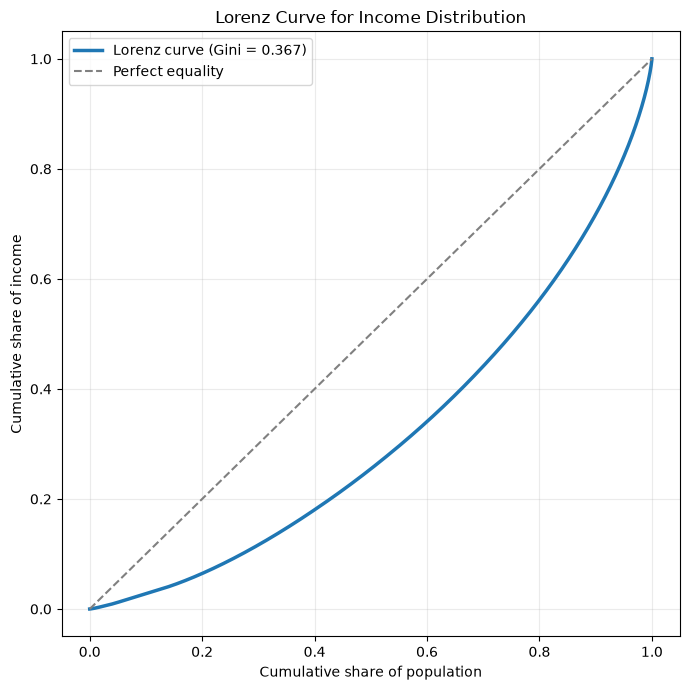

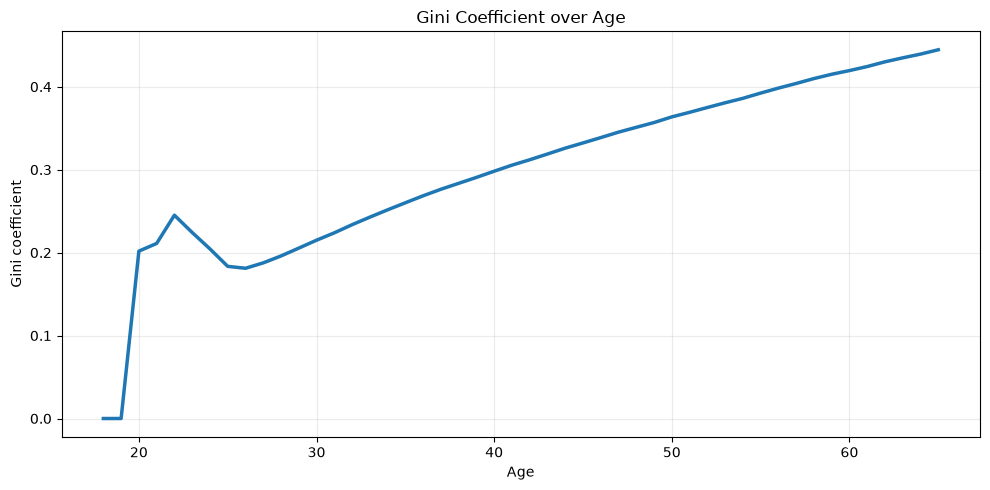

In [8]:
    # 1) Lorenz curve for all persons (pooled across all ages)
income_all_people = income.ravel()
cum_pop, cum_inc = dp.lorenz_curve(income_all_people)
gini_all_people = dp.gini_coefficient(income_all_people)

plt.figure(figsize=(7, 7))
plt.plot(cum_pop, cum_inc, label=f"Lorenz curve (Gini = {gini_all_people:.3f})", linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect equality")
plt.title("Lorenz Curve for Income Distribution")
plt.xlabel("Cumulative share of population")
plt.ylabel("Cumulative share of income")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Gini coefficient by age
gini_by_age_series = np.array([dp.gini_coefficient(income[:, t]) for t in range(len(ages))])

plt.figure(figsize=(10, 5))
plt.plot(ages, gini_by_age_series, linewidth=2.5)
plt.title("Gini Coefficient over Age")
plt.xlabel("Age")
plt.ylabel("Gini coefficient")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Inequality within age groups is generally lower than inequality in the pooled sample, although it increases steadily with age. The Gini coefficient rises from around 0.2 for younger individuals to approximately 0.45 at age 65, reflecting the accumulation of differences in education, employment histories, and human capital over time. However, the Gini coefficient for the pooled sample is 0.368, which captures not only inequality within each age group but also income differences between age groups. Thus, overall inequality is driven by both life-cycle income growth and dispersion within cohorts.

## Task 2.4 - What drives inequality?

In [9]:
scenarios = {
    "Baseline":                         dict(education_on=True,  shocks_on=True,  depreciation_on=True,  unemployment_on=True),
    "No ed. differences":        dict(education_on=False, shocks_on=True,  depreciation_on=True,  unemployment_on=True),
    "No shocks to human capital":       dict(education_on=True,  shocks_on=False, depreciation_on=True,  unemployment_on=True),
    "No depreciation during unemployment": dict(education_on=True,  shocks_on=True,  depreciation_on=False, unemployment_on=True),
    "No unemployment":                    dict(education_on=True,  shocks_on=True,  depreciation_on=True,  unemployment_on=False),
}

rows = []
scenario_incomes = {}
for name, flags in scenarios.items():
    st, hc, inc, ag, eg = dp.simulate_income(
        N=N, Pe=Pe, Se=Se, He=He, growth=growth, depreciation=depreciation, std=std,
        job_finding=job_finding, job_separation=job_separation, grant=grant,
        replacement=replacement, benefit_floor=benefit_floor,
        start_age=start_age, retire_age=retire_age, seed=seed, **flags,
    )
    scenario_incomes[name] = inc
    rows.append({
        "Scenario": name,
        "Gini (pooled)": dp.gini_coefficient(inc.ravel()),
        "Gini (at pension)": dp.gini_coefficient(inc[:, -1]),
    })

results_df = pd.DataFrame(rows).set_index("Scenario")
baseline_gini = results_df.loc["Baseline", "Gini (pooled)"]
baseline_gini_pension = results_df.loc["Baseline", "Gini (at pension)"]
results_df["Changed compared to baseline at retirement"] = results_df["Gini (at pension)"] - baseline_gini_pension
results_df["Changed compared to baseline"] = results_df["Gini (pooled)"] - baseline_gini

display(results_df.round(4))

,Gini (pooled),Gini (at pension),Changed compared to baseline at retirement,Changed compared to baseline
Scenario,,,,
Baseline,0.3672,0.4446,0.0000,0.0000
No ed. differences,0.3203,0.3763,-0.0683,-0.0469
No shocks to human capital,0.2731,0.2927,-0.1519,-0.0941
No depreciation during unemployment,0.3730,0.4309,-0.0137,0.0057
No unemployment,0.3718,0.4328,-0.0118,0.0046


The table above reports the Gini coefficient for the baseline model and for alternative simulations where individual mechanisms are switched off. The results show that shocks to human capital are the most important driver of inequality. When these shocks are removed, the pooled Gini coefficient falls from 0.369 to 0.274, a reduction of almost 0.095. Educational differences are also important, reducing the pooled Gini coefficient to 0.321 when removed. In contrast, removing unemployment or human-capital depreciation during unemployment has only a minor impact on overall inequality.

The results at retirement age show an even stronger effect of human-capital shocks. The Gini coefficient falls from 0.446 in the baseline model to 0.291 when shocks are removed. This suggests that random differences in human-capital accumulation compound over the life cycle and generate substantial dispersion in income. Educational differences also contribute to inequality, while unemployment-related mechanisms play a relatively small role. Overall, human-capital shocks appear to be the dominant source of inequality in the model.

## 2.5 Extension: Inheritance shock

We add an extra source of risk: at age 40, a random share of the population receives an inheritance in the form of a lump-sum payment. We use a probability of `inheritance_prob = 0.20`, and let the size of the inheritance be lognormally distributed, so that most recipients get a moderate inheritance, but a few receive a much larger one (similar to how wealth/inheritance is typically skewed in real data).

The inheritance is added directly on top of income in the year the person turns 40 – it does not affect employment status or human capital, only income in that particular year.

In [10]:
# Parameters for the inheritance shock
inheritance_prob = 0.20        # share of the population that receives an inheritance
inheritance_age = 40           # age at which the inheritance is paid out
inheritance_mean_log = np.log(2.0)  # median inheritance ~ 2x an average annual income
inheritance_std_log = 0.75          # spread (skewness) of the inheritance size

rng_inheritance = np.random.default_rng(seed + 1)  # separate rng, so the baseline simulation is unaffected

receives_inheritance = rng_inheritance.random(N) < inheritance_prob
inheritance_amount = np.zeros(N)
inheritance_amount[receives_inheritance] = rng_inheritance.lognormal(
    mean=inheritance_mean_log, sigma=inheritance_std_log, size=receives_inheritance.sum()
)

print(f"Share receiving an inheritance: {receives_inheritance.mean():.3f}, Target: {inheritance_prob:.3f}")
print(f"Average inheritance among recipients: {inheritance_amount[receives_inheritance].mean():.3f}")
print(f"Median inheritance among recipients: {np.median(inheritance_amount[receives_inheritance]):.3f}")


Share receiving an inheritance: 0.199, Target: 0.200
Average inheritance among recipients: 2.669
Median inheritance among recipients: 2.022


In [11]:
# Add the inheritance on top of income in the year the person turns inheritance_age
income_with_inheritance = income.copy()
age_idx_40 = np.where(ages == inheritance_age)[0][0]
income_with_inheritance[:, age_idx_40] += inheritance_amount

print(f"Total income at age {inheritance_age}, without inheritance: {income[:, age_idx_40].sum():,.1f}")
print(f"Total income at age {inheritance_age}, with inheritance:    {income_with_inheritance[:, age_idx_40].sum():,.1f}")


Total income at age 40, without inheritance: 71,425.5
Total income at age 40, with inheritance:    98,043.7


In [12]:
# Gini coefficient with and without the inheritance shock
gini_pooled_baseline = dp.gini_coefficient(income.ravel())
gini_pooled_inheritance = dp.gini_coefficient(income_with_inheritance.ravel())

gini_age40_baseline = dp.gini_coefficient(income[:, age_idx_40])
gini_age40_inheritance = dp.gini_coefficient(income_with_inheritance[:, age_idx_40])

print("Gini coefficient, all ages pooled:")
print(f"  Without inheritance shock: {gini_pooled_baseline:.4f}")
print(f"  With inheritance shock:    {gini_pooled_inheritance:.4f}")
print()
print(f"Gini coefficient at age {inheritance_age}:")
print(f"  Without inheritance shock: {gini_age40_baseline:.4f}")
print(f"  With inheritance shock:    {gini_age40_inheritance:.4f}")


Gini coefficient, all ages pooled:
  Without inheritance shock: 0.3672
  With inheritance shock:    0.3699

Gini coefficient at age 40:
  Without inheritance shock: 0.2981
  With inheritance shock:    0.3897


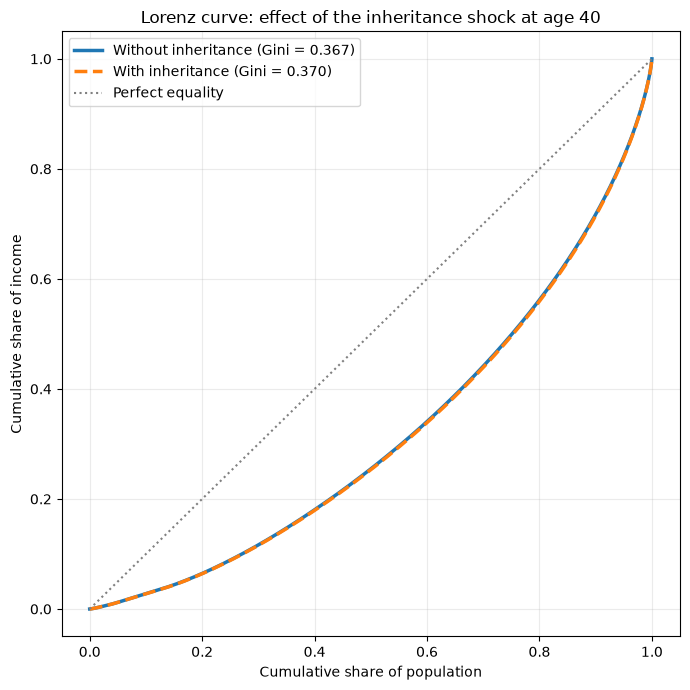

In [13]:
# Lorenz curve: effect of the inheritance shock (pooled across all ages)
cum_pop_base, cum_inc_base = dp.lorenz_curve(income.ravel())
cum_pop_inh, cum_inc_inh = dp.lorenz_curve(income_with_inheritance.ravel())

plt.figure(figsize=(7, 7))
plt.plot(cum_pop_base, cum_inc_base, label=f"Without inheritance (Gini = {gini_pooled_baseline:.3f})", linewidth=2.5)
plt.plot(cum_pop_inh, cum_inc_inh, label=f"With inheritance (Gini = {gini_pooled_inheritance:.3f})", linewidth=2.5, linestyle="--")
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", label="Perfect equality")
plt.title("Lorenz curve: effect of the inheritance shock at age 40")
plt.xlabel("Cumulative share of population")
plt.ylabel("Cumulative share of income")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


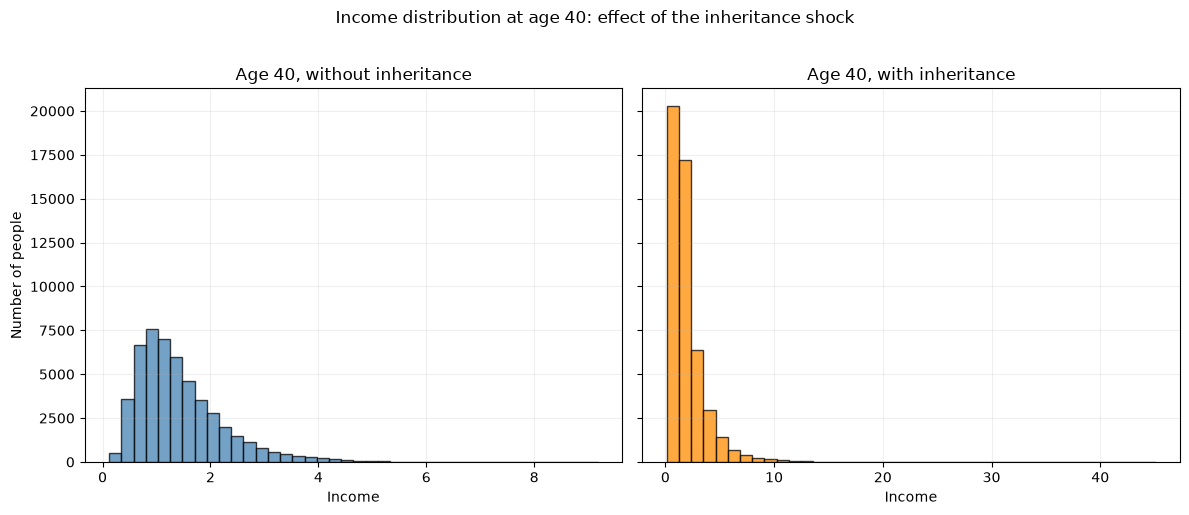

In [14]:
# Histogram: income distribution at age 40, with and without inheritance
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(income[:, age_idx_40], bins=40, edgecolor="black", alpha=0.75, color="steelblue")
axes[0].set_title(f"Age {inheritance_age}, without inheritance")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Number of people")
axes[0].grid(alpha=0.2)

axes[1].hist(income_with_inheritance[:, age_idx_40], bins=40, edgecolor="black", alpha=0.75, color="darkorange")
axes[1].set_title(f"Age {inheritance_age}, with inheritance")
axes[1].set_xlabel("Income")
axes[1].grid(alpha=0.2)

plt.suptitle("Income distribution at age 40: effect of the inheritance shock", y=1.02)
plt.tight_layout()
plt.show()


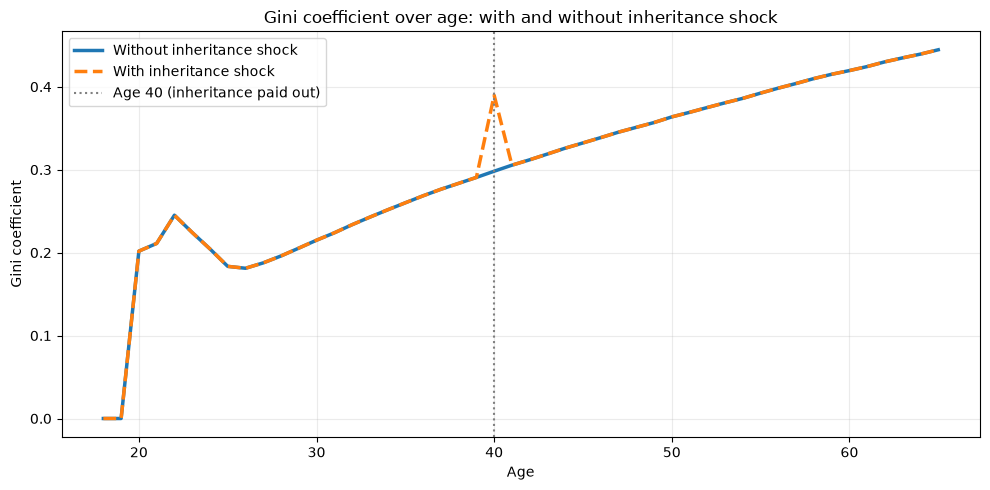

In [15]:
# Gini coefficient over age: with and without the inheritance shock
gini_by_age_base = np.array([dp.gini_coefficient(income[:, t]) for t in range(len(ages))])
gini_by_age_inh = np.array([dp.gini_coefficient(income_with_inheritance[:, t]) for t in range(len(ages))])

plt.figure(figsize=(10, 5))
plt.plot(ages, gini_by_age_base, label="Without inheritance shock", linewidth=2.5)
plt.plot(ages, gini_by_age_inh, label="With inheritance shock", linewidth=2.5, linestyle="--")
plt.axvline(inheritance_age, color="gray", linestyle=":", label=f"Age {inheritance_age} (inheritance paid out)")
plt.title("Gini coefficient over age: with and without inheritance shock")
plt.xlabel("Age")
plt.ylabel("Gini coefficient")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation:** The inheritance shock only hits in the year the person turns 40, and is uncorrelated with the person's income history (it only depends on whether they happen to be among the 20% who receive an inheritance). This produces a sizable but temporary jump in the Gini coefficient *at age 40* – some people receive a large lump sum on top of their usual wage/benefits, while 80% get nothing extra. In comparison, the effect on the *pooled* Gini coefficient (all ages combined) is small, because the inheritance affects only one out of the 48 years of life covered by the simulation. For a more persistent effect, one could, for example, let the inheritance be invested and generate a return for the rest of the person's life, or let the size of the inheritance depend on the parents' income (inheritance from parents is typically not randomly distributed in real data).